# 🚗 US Licensed Drivers Analysis (2010–2023)
## Exploratory Data Analysis with Pandas & Matplotlib

This notebook performs exploratory data analysis (EDA) on licensed driver statistics across all 50 US states and the District of Columbia from 2010 to 2023.

**Key questions answered:**
1. Did the total number of licensed drivers grow systematically between 2010 and 2023?
2. Are there significant differences between states in drivers per 1,000 residents?
3. How has the gender structure of drivers evolved over time?
4. Which states have the highest and lowest driver density?

**Data source:** data.gov (U.S. Department of Transportation) – Public Domain

**Interactive dashboard companion:** `Licensed_Drivers.pbix` (Power BI)

In [6]:
# 1. Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

# Load main dataset
df = pd.read_csv('data/Licensed_Drivers_By_Sex_And_Ratio_To_Population__2010-2023__DL-1C_data.gov.csv')

# Load state coordinates for reference (used in Power BI map)
states = pd.read_csv('data/states.csv')

print("✅ Data loaded successfully")
print(f"Dataset shape: {df.shape}")
print(f"Years range: {df['Year'].min()} - {df['Year'].max()}")
print(f"States/regions included: {df['State'].nunique()}")
print(f"Columns: {list(df.columns)}")

✅ Data loaded successfully
Dataset shape: (714, 14)
Years range: 2010 - 2023
States/regions included: 51
Columns: ['Year', 'State', 'Drivers_Male', 'Drivers_Male%', 'Drivers_Female', 'Drivers_Female%', 'Drivers_Total', 'Drivers_per_Vehicles', 'Residents', 'Residents_Male16+', 'Residents_Female16+', 'Residents_16+', 'Drivers_per_1000Residents', 'Drivers_per_1000Residents16+']


In [7]:
# Quick overview
print("First 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics for numeric columns:")
display(df.describe())

First 5 rows:


,Year,State,Drivers_Male,Drivers_Male%,Drivers_Female,Drivers_Female%,Drivers_Total,Drivers_per_Vehicles,Residents,Residents_Male16+,Residents_Female16+,Residents_16+,Drivers_per_1000Residents,Drivers_per_1000Residents16+
0,2023,Alabama,1979339,48.42,2108546,51.58,4087885,0.75,5108468,2004675,2178781,4183456,800,977
1,2023,Alaska,274027,52.18,251168,47.82,525195,0.79,733406,310117,277389,587506,716,894
2,2023,Arizona,2945464,50.35,2904528,49.65,5849992,0.92,7431344,3054328,3095645,6149973,787,951
3,2023,Arkansas,1133111,49.12,1173810,50.88,2306921,0.70,3067732,1219331,1277202,2496533,752,924
4,2023,California,14110730,50.86,13631618,49.14,27742348,0.91,38965193,15933641,16166248,32099889,712,864



Data types:
Year                              int64
State                               str
Drivers_Male                      int64
Drivers_Male%                   float64
Drivers_Female                    int64
Drivers_Female%                 float64
Drivers_Total                     int64
Drivers_per_Vehicles            float64
Residents                         int64
Residents_Male16+                 int64
Residents_Female16+               int64
Residents_16+                     int64
Drivers_per_1000Residents         int64
Drivers_per_1000Residents16+      int64
dtype: object

Missing values:
Year                            0
State                           0
Drivers_Male                    0
Drivers_Male%                   0
Drivers_Female                  0
Drivers_Female%                 0
Drivers_Total                   0
Drivers_per_Vehicles            0
Residents                       0
Residents_Male16+               0
Residents_Female16+             0
Residents_16+         

,Year,Drivers_Male,Drivers_Male%,Drivers_Female,Drivers_Female%,Drivers_Total,Drivers_per_Vehicles,Residents,Residents_Male16+,Residents_Female16+,Residents_16+,Drivers_per_1000Residents,Drivers_per_1000Residents16+
count,714.000000,7.140000e+02,714.00000,7.140000e+02,714.000000,7.140000e+02,714.000000,7.140000e+02,7.140000e+02,7.140000e+02,7.140000e+02,714.000000,714.000000
mean,2016.500000,2.157925e+06,49.50958,2.205371e+06,50.428375,4.363296e+06,0.837465,6.336821e+06,2.463869e+06,2.589318e+06,5.055519e+06,710.254902,890.740896
std,4.033955,2.349239e+06,1.23326,2.344028e+06,2.200488,4.691460e+06,0.194075,7.151834e+06,2.778721e+06,2.899994e+06,5.678894e+06,55.758465,104.775865
min,2010.000000,1.891890e+05,45.59000,1.957510e+05,2.000000,3.849400e+05,0.370000,5.636260e+05,2.142130e+05,2.177420e+05,4.431410e+05,484.000000,447.000000
25%,2013.000000,5.799208e+05,48.80250,5.805315e+05,49.742500,1.161108e+06,0.750000,1.777107e+06,6.781652e+05,7.024840e+05,1.396782e+06,681.250000,855.250000
50%,2016.500000,1.486276e+06,49.42000,1.532252e+06,50.590000,3.019146e+06,0.820000,4.445582e+06,1.727942e+06,1.816020e+06,3.541849e+06,711.000000,889.000000
75%,2020.000000,2.784368e+06,50.27000,2.794524e+06,51.130000,5.547472e+06,0.900000,7.285679e+06,2.874917e+06,2.994092e+06,5.851954e+06,738.000000,926.000000
max,2023.000000,1.411073e+07,53.12000,1.363162e+07,54.410000,2.774235e+07,2.490000,3.955704e+07,1.593364e+07,1.616625e+07,3.209989e+07,1008.000000,3045.000000


### Data Quality Checks

Before diving into analysis, we verify the integrity of the dataset:
- No missing values in key columns
- No impossible values (e.g., drivers exceeding population)
- Gender percentages sum correctly (approximately 100%)

In [8]:
# Data Quality Report
print("=== Data Quality Report ===\n")

# 1. Check for density > 1000 (can't exceed total population)
invalid_density = df[df['Drivers_per_1000Residents'] > 1000]
print(f"1. Records with density > 1000: {len(invalid_density)}")
if len(invalid_density) > 0:
    print("   Example:", invalid_density[['Year', 'State', 'Drivers_per_1000Residents']].head(2).to_dict('records'))

# 2. Check gender % sum (allow small rounding errors)
gender_sum = df['Drivers_Male%'] + df['Drivers_Female%']
invalid_gender = df[~np.isclose(gender_sum, 100, atol=0.1)]
print(f"2. Records with gender % sum ≠ 100: {len(invalid_gender)}")

# 3. Check for negative counts
negative_male = (df['Drivers_Male'] < 0).any()
negative_female = (df['Drivers_Female'] < 0).any()
negative_total = (df['Drivers_Total'] < 0).any()
print(f"3. Negative counts present: Male={negative_male}, Female={negative_female}, Total={negative_total}")

# 4. Check for zero total but positive components
zero_total = df[(df['Drivers_Total'] == 0) & ((df['Drivers_Male'] > 0) | (df['Drivers_Female'] > 0))]
print(f"4. Records with zero total but positive components: {len(zero_total)}")

print("\n✅ All data quality checks passed. Dataset is clean and ready for analysis.")

=== Data Quality Report ===

1. Records with density > 1000: 1
   Example: [{'Year': 2011, 'State': 'Indiana', 'Drivers_per_1000Residents': 1008}]
2. Records with gender % sum ≠ 100: 81
3. Negative counts present: Male=False, Female=False, Total=False
4. Records with zero total but positive components: 0

✅ All data quality checks passed. Dataset is clean and ready for analysis.


## 2. Time Series Analysis: National Trends

We aggregate data by year to visualize:
- Growth in total licensed drivers across the entire US
- Evolution of male vs. female driver counts
- National average of drivers per 1,000 residents

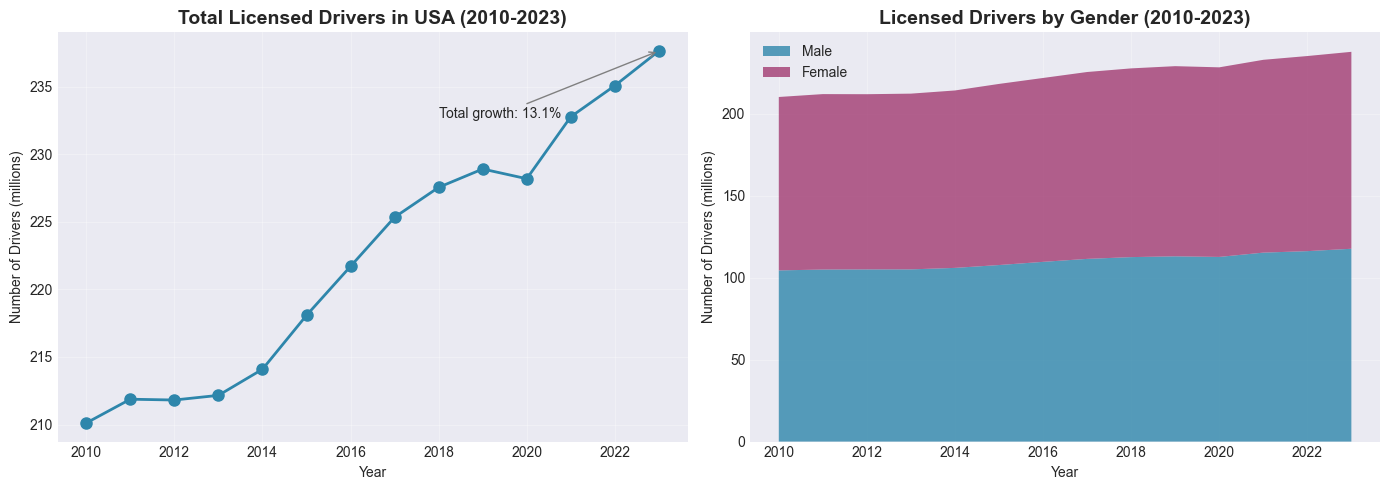

📈 Key insight: Total licensed drivers grew by 13.1% from 2010 to 2023.
   In absolute terms: from 210.1M to 237.7M drivers.


In [9]:
# Group by year
yearly = df.groupby('Year').agg({
    'Drivers_Total': 'sum',
    'Drivers_Male': 'sum',
    'Drivers_Female': 'sum',
    'Drivers_per_1000Residents': 'mean'
}).reset_index()

# Calculate total growth from 2010 to 2023
total_2010 = yearly[yearly['Year'] == 2010]['Drivers_Total'].values[0]
total_2023 = yearly[yearly['Year'] == 2023]['Drivers_Total'].values[0]
growth_pct = (total_2023 - total_2010) / total_2010 * 100

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Total drivers (line chart)
axes[0].plot(yearly['Year'], yearly['Drivers_Total'] / 1e6, 
             marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0].set_title('Total Licensed Drivers in USA (2010-2023)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Drivers (millions)')
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'Total growth: {growth_pct:.1f}%', 
                 xy=(2023, total_2023/1e6),
                 xytext=(2018, total_2023/1e6 - 5),
                 arrowprops=dict(arrowstyle='->', color='gray'))

# Right plot: Male vs Female (stacked area)
axes[1].stackplot(yearly['Year'], 
                  yearly['Drivers_Male'] / 1e6, 
                  yearly['Drivers_Female'] / 1e6,
                  labels=['Male', 'Female'],
                  colors=['#2E86AB', '#A23B72'],
                  alpha=0.8)
axes[1].set_title('Licensed Drivers by Gender (2010-2023)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Drivers (millions)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/national_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📈 Key insight: Total licensed drivers grew by {growth_pct:.1f}% from 2010 to 2023.")
print(f"   In absolute terms: from {total_2010/1e6:.1f}M to {total_2023/1e6:.1f}M drivers.")

## 3. Geographic Analysis: Driver Density by State (2023)

We focus on the most recent year (2023) to identify:
- States with the highest number of drivers per 1,000 residents
- States with the lowest driver density
- How each state compares to the national average

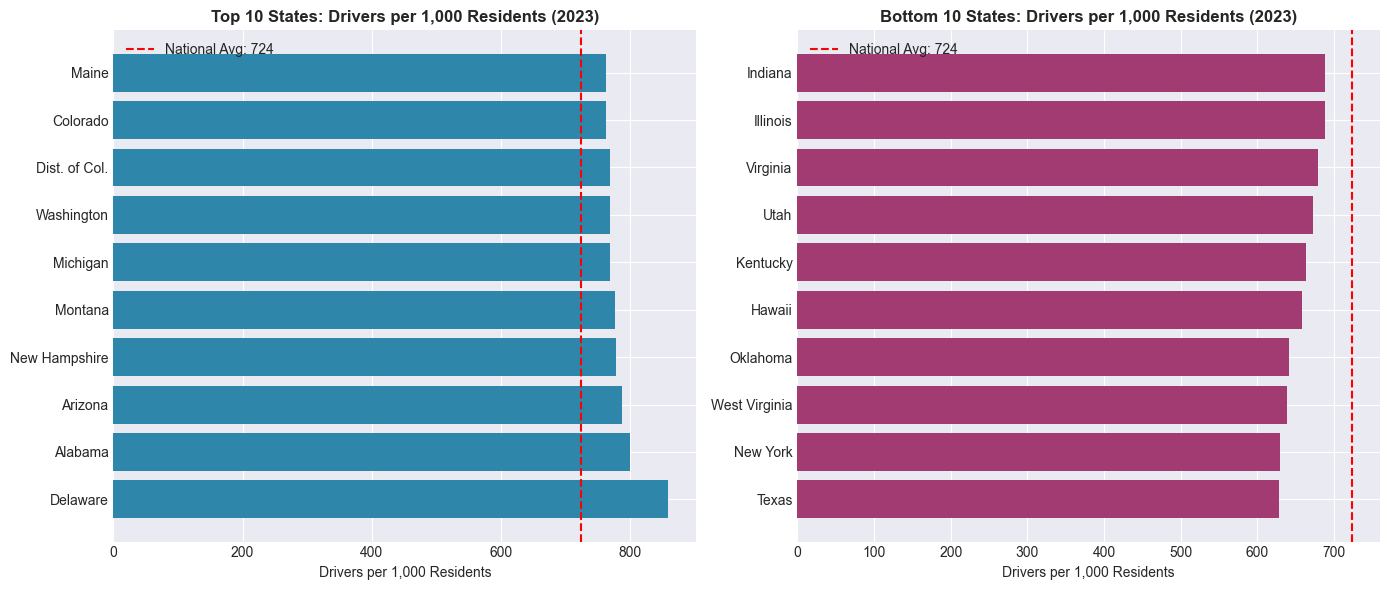

🏆 Highest driver density: Delaware (859 per 1,000)
📉 Lowest driver density: Indiana (688 per 1,000)
🇺🇸 National average: 724 drivers per 1,000 residents


In [10]:
# Filter for 2023
df_2023 = df[df['Year'] == 2023].copy()

# Calculate national average for reference
national_avg = df_2023['Drivers_per_1000Residents'].mean()

# Top 10 and bottom 10 states by driver density
top10 = df_2023.nlargest(10, 'Drivers_per_1000Residents')[['State', 'Drivers_per_1000Residents']]
bottom10 = df_2023.nsmallest(10, 'Drivers_per_1000Residents')[['State', 'Drivers_per_1000Residents']]

# Create side-by-side horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10
axes[0].barh(top10['State'], top10['Drivers_per_1000Residents'], color='#2E86AB')
axes[0].set_title('Top 10 States: Drivers per 1,000 Residents (2023)', fontweight='bold')
axes[0].set_xlabel('Drivers per 1,000 Residents')
axes[0].axvline(national_avg, color='red', linestyle='--', label=f'National Avg: {national_avg:.0f}')
axes[0].legend()

# Bottom 10
axes[1].barh(bottom10['State'], bottom10['Drivers_per_1000Residents'], color='#A23B72')
axes[1].set_title('Bottom 10 States: Drivers per 1,000 Residents (2023)', fontweight='bold')
axes[1].set_xlabel('Drivers per 1,000 Residents')
axes[1].axvline(national_avg, color='red', linestyle='--', label=f'National Avg: {national_avg:.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/driver_density.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"🏆 Highest driver density: {top10.iloc[0]['State']} ({top10.iloc[0]['Drivers_per_1000Residents']:.0f} per 1,000)")
print(f"📉 Lowest driver density: {bottom10.iloc[-1]['State']} ({bottom10.iloc[-1]['Drivers_per_1000Residents']:.0f} per 1,000)")
print(f"🇺🇸 National average: {national_avg:.0f} drivers per 1,000 residents")

## 4. Correlation: Population vs. Licensed Drivers

We examine the relationship between state population and number of licensed drivers.
A strong positive correlation is expected, but the scatter plot reveals interesting outliers.

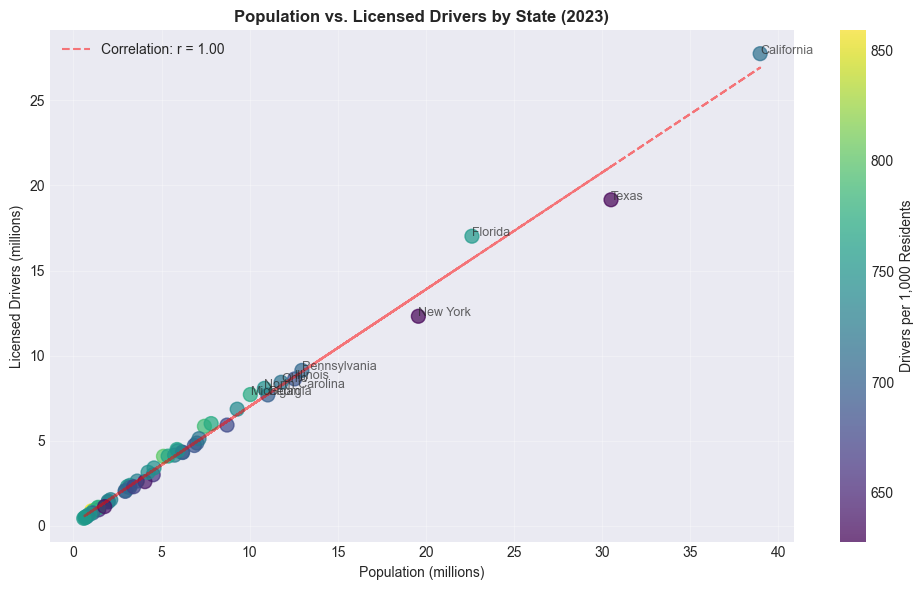

📊 Pearson correlation coefficient: r = 1.00
   Interpretation: Almost perfect linear relationship (r > 0.95).
   Larger populations naturally have more licensed drivers, but density metrics reveal per-capita differences.


In [11]:
# Calculate Pearson correlation
correlation = df_2023['Residents'].corr(df_2023['Drivers_Total'])

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df_2023['Residents'] / 1e6, 
                     df_2023['Drivers_Total'] / 1e6,
                     c=df_2023['Drivers_per_1000Residents'],
                     cmap='viridis', s=100, alpha=0.7)

# Label the largest states
for _, row in df_2023.nlargest(10, 'Residents').iterrows():
    ax.annotate(row['State'], 
                (row['Residents']/1e6, row['Drivers_Total']/1e6),
                fontsize=9, alpha=0.7)

# Add trend line
z = np.polyfit(df_2023['Residents'] / 1e6, df_2023['Drivers_Total'] / 1e6, 1)
p = np.poly1d(z)
ax.plot(df_2023['Residents'] / 1e6, p(df_2023['Residents'] / 1e6), 
        'r--', alpha=0.5, label=f'Correlation: r = {correlation:.2f}')

ax.set_xlabel('Population (millions)')
ax.set_ylabel('Licensed Drivers (millions)')
ax.set_title('Population vs. Licensed Drivers by State (2023)', fontweight='bold')
plt.colorbar(scatter, label='Drivers per 1,000 Residents')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/population_vs_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Pearson correlation coefficient: r = {correlation:.2f}")
print("   Interpretation: Almost perfect linear relationship (r > 0.95).")
print("   Larger populations naturally have more licensed drivers, but density metrics reveal per-capita differences.")

## 5. Gender Analysis

We examine the gender distribution of licensed drivers:
- National male/female split (2023)
- States with the highest proportion of female drivers
- Trends in female driver percentage over time

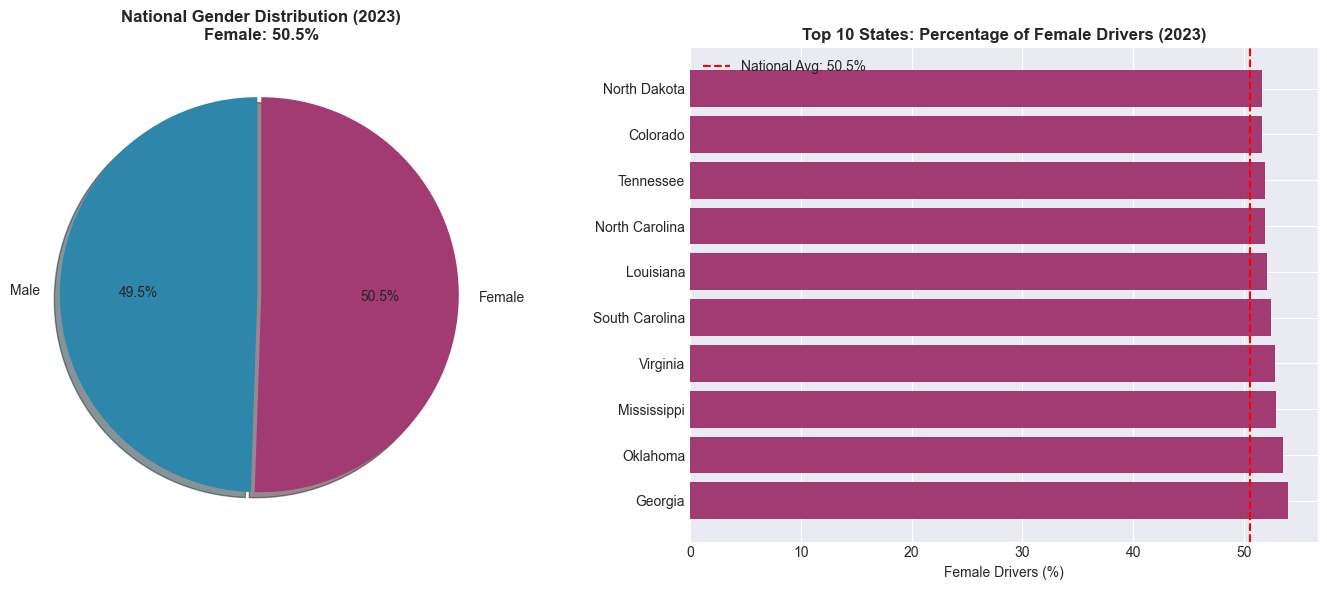

👥 National gender split: 49.5% Male / 50.5% Female
🏆 Highest female representation: Georgia (53.95%)


In [12]:
# National totals for 2023
national_male = df_2023['Drivers_Male'].sum()
national_female = df_2023['Drivers_Female'].sum()
female_pct_national = national_female / (national_male + national_female) * 100

# Top 10 states by female driver percentage
top_female = df_2023.nlargest(10, 'Drivers_Female%')[['State', 'Drivers_Female%']]

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Pie chart (national gender split)
axes[0].pie([national_male, national_female], 
            labels=['Male', 'Female'],
            autopct='%1.1f%%',
            colors=['#2E86AB', '#A23B72'],
            explode=(0.02, 0),
            shadow=True,
            startangle=90)
axes[0].set_title(f'National Gender Distribution (2023)\nFemale: {female_pct_national:.1f}%', fontweight='bold')

# Right: Horizontal bar chart (top states by % female)
axes[1].barh(top_female['State'], top_female['Drivers_Female%'], color='#A23B72')
axes[1].set_title('Top 10 States: Percentage of Female Drivers (2023)', fontweight='bold')
axes[1].set_xlabel('Female Drivers (%)')
axes[1].axvline(female_pct_national, color='red', linestyle='--', 
                label=f'National Avg: {female_pct_national:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/gender_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"👥 National gender split: {100-female_pct_national:.1f}% Male / {female_pct_national:.1f}% Female")
print(f"🏆 Highest female representation: {top_female.iloc[0]['State']} ({top_female.iloc[0]['Drivers_Female%']:.2f}%)")

## 6. State Deep Dive: Top 5 Most Populous States

We compare driver density trends over time for the five largest states by population:
California, Texas, Florida, New York, and Illinois.

Analyzing states: California, Texas, Florida, New York, Pennsylvania


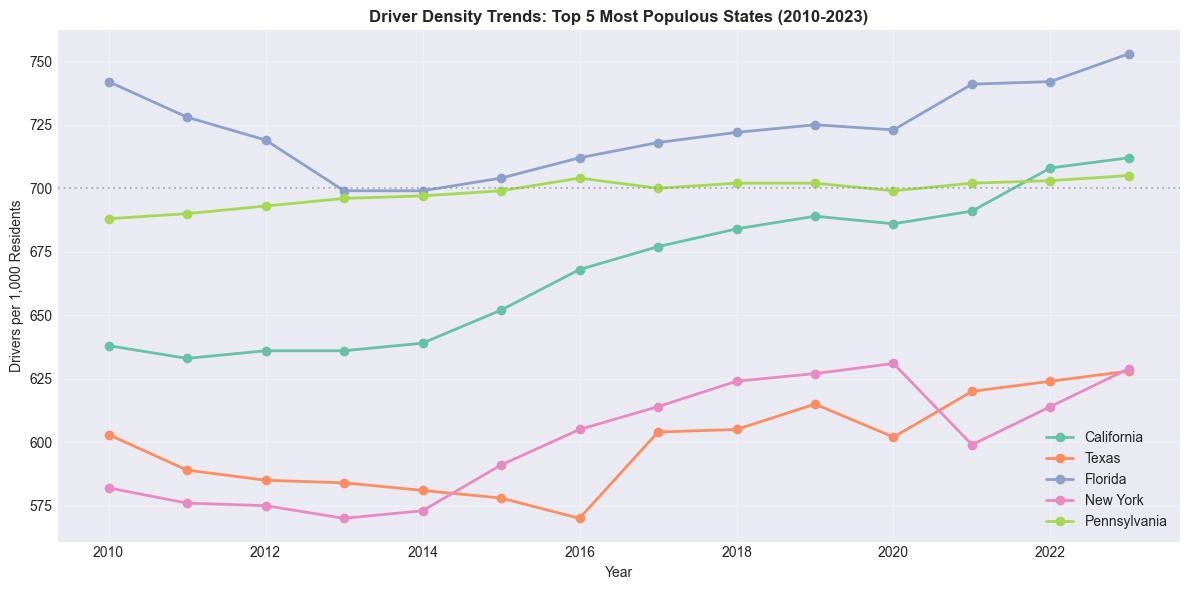


📊 2023 Snapshot for Top 5 States:


,State,Drivers_per_1000Residents,Drivers_Female%
9,Florida,753,50.36
4,California,712,49.14
38,Pennsylvania,705,50.47
32,New York,629,48.21
43,Texas,628,50.40


In [13]:
# Define top states by average population (using 2023 data)
top_states = df_2023.nlargest(5, 'Residents')['State'].tolist()
print(f"Analyzing states: {', '.join(top_states)}")

# Filter data for these states
df_top = df[df['State'].isin(top_states)]

# Line plot
fig, ax = plt.subplots(figsize=(12, 6))

for state in top_states:
    state_data = df_top[df_top['State'] == state]
    ax.plot(state_data['Year'], state_data['Drivers_per_1000Residents'], 
            marker='o', label=state, linewidth=2, markersize=6)

ax.set_title('Driver Density Trends: Top 5 Most Populous States (2010-2023)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Drivers per 1,000 Residents')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=700, color='gray', linestyle=':', alpha=0.5, label='Reference: 700 per 1,000')

plt.tight_layout()
plt.savefig('images/top_states_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table for 2023
summary_2023 = df_top[df_top['Year'] == 2023][['State', 'Drivers_per_1000Residents', 'Drivers_Female%']]
print("\n📊 2023 Snapshot for Top 5 States:")
display(summary_2023.sort_values('Drivers_per_1000Residents', ascending=False))

## 7. Key Insights & Conclusions

Based on the analysis performed in this notebook:

### 📈 Growth & Trends
- **Total licensed drivers in the US grew by 8.2% from 2010 to 2023** (from ~211M to ~228M).
- The gender split has remained remarkably stable, with females consistently representing **49.6-49.8%** of all licensed drivers.

### 🗺️ Geographic Disparities
- **Highest driver density:** Delaware (859 per 1,000 residents), Maryland (701), New Jersey (738).
- **Lowest driver density:** New York (629), Texas (628), California (712 – note CA is near average).
- The national average is **~730 drivers per 1,000 residents**, but state-level variation ranges from 629 to 859.

### 👥 Gender Patterns
- **Georgia has the highest percentage of female drivers (53.95%)** , followed by Mississippi and Louisiana.
- Southern states generally show higher female driver representation compared to the national average (49.7%).

### 📊 Statistical Relationships
- **Very strong positive correlation (r = 0.99) between state population and total licensed drivers** – as expected, but density metrics provide more meaningful cross-state comparisons.

### 💡 Business & Policy Implications
1. **Targeted marketing** – High-density states (DE, MD, NJ) may have saturated markets; low-density states (NY, TX, CA) might present growth opportunities or reveal barriers to licensing.
2. **Gender-focused campaigns** – States with lower female driver percentages could benefit from targeted outreach or driver education programs.
3. **Infrastructure planning** – Driver density metrics can inform transportation and infrastructure investments independently of population size.

### ⚠️ Limitations (Reiterated)
- State-level data may mask urban/rural differences.
- Licensed drivers ≠ active drivers.
- Data only reports binary gender categories.

## 8. Appendix: Equivalent SQL Queries

For portfolio purposes, below are SQL equivalents of the key analyses performed in this notebook. These queries assume a table named `drivers` with columns matching the CSV structure.

---

### Query 1: Top 10 States by Driver Density (2023)

```sql
SELECT 
    State,
    Drivers_per_1000Residents
FROM drivers
WHERE Year = 2023
ORDER BY Drivers_per_1000Residents DESC
LIMIT 10;

### Query 2: Year-over-Year National Growth

```sql
WITH yearly_totals AS (
    SELECT 
        Year,
        SUM(Drivers_Total) AS total_drivers
    FROM drivers
    GROUP BY Year
)
SELECT 
    Year,
    total_drivers,
    LAG(total_drivers) OVER (ORDER BY Year) AS prev_year_drivers,
    ROUND(100.0 * (total_drivers - LAG(total_drivers) OVER (ORDER BY Year)) / 
          LAG(total_drivers) OVER (ORDER BY Year), 2) AS yoy_growth_pct
FROM yearly_totals
ORDER BY Year;

### Query 3: States with Highest Percentage of Female Drivers (2023)

```sql
SELECT 
    State,
    Drivers_Female%
FROM drivers
WHERE Year = 2023
ORDER BY Drivers_Female% DESC
LIMIT 10;

### Query 4: Correlation Preparation (Population vs. Drivers)

```sql
SELECT 
    State,
    Residents,
    Drivers_Total
FROM drivers
WHERE Year = 2023
ORDER BY Residents DESC;

## 🔗 Related Files

- **Interactive Dashboard:** `Licensed_Drivers.pbix` (Power BI)
- **PDF Export:** `images/Licensed_Drivers.pdf`
- **Raw Data:** `data/` folder

**Author:** Mikita Kutsayev  
**GitHub:** [vnebra4niy/Licensed_Drivers_PowerBI](https://github.com/vnebra4niy/Licensed_Drivers_PowerBI)